In LangChain, a “conversation” is represented as a sequence of Message objects.
The most common ones are:
- HumanMessage — content written by the user
- AIMessage — content written by the model
- SystemMessage — instructions for how the model should behave
- ToolMessage — responses from tool calls (when using agents)

In [1]:
import logging
logging.basicConfig(
    level=logging.DEBUG,  # Set the logging level (e.g., DEBUG, INFO, WARNING, ERROR)
    format='%(asctime)s - %(name)s - %(levelname)s - %(filename)s:%(lineno)d - %(funcName)s() - %(message)s'
)
logger = logging.getLogger("__name__")
logger.setLevel(logging.WARN)

In [2]:
from typing import Literal, TypedDict, Any
from pydantic import BaseModel, Field, ConfigDict
class GraphState(BaseModel):
    """Represents the state of our graph in the agentic AI workflow."""
    task: str = Field(description="The original user task, e.g., 'Write a report on renewable energy.'")
    stage: Literal["plan", "research", "write", "review", "done"] = Field(
        description="The current stage of the workflow the agent is in."
    )
    context: str = Field(
        default="",
        description="Running context notes and scratchpad passed between agents."
    )
    draft: str = Field(
        default="",
        description="The writer agent's current draft of the final output."
    )
    citations: list[str] = Field(
        default_factory=list, # Use default_factory for mutable types like lists
        description="A list of URLs gathered by the researcher agent as sources."
    )
    supervisor_note: str = Field(
        default="",
        description="The supervisor agent's last routing decision or instructions."
    )

    model_config = ConfigDict(
        # This adds an 'example' to the JSON schema for documentation/API UIs
        json_schema_extra={
            "example": {
                "task": "Write a short report on the benefits of solar power.",
                "stage": "plan",
                "context": "The user wants a concise summary of solar energy benefits.",
                "draft": "",
                "citations": [],
                "supervisor_note": "Starting the planning phase for the user request.",
            }
        }
    )


# class GraphState(TypedDict):
#     task: str                       # the original user task
#     stage: Literal["plan","research","write","review","done"]
#     context: str                    # running context notes passed between agents
#     draft: str                      # writer's current draft
#     citations: list[str]            # urls gathered by researcher
#     supervisor_note: str            # supervisor's last routing decision

# Helper functions (LLM, web-search)

In [ ]:
import time
from ddgs import DDGS   # <-- correct import
def web_search(query: str, k: int = 5) -> list[dict]:
    """
    Returns up to `k` search results.
    Handles rate-limits, Bing fallback, and empty responses.
    """
    # Real-browser headers – prevents instant blocking
    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/129.0.0.0 Safari/537.36"
        ),
        "Accept-Language": "en-US,en;q=0.9",
    }

    try:
        with DDGS(headers=headers, timeout=20) as ddg:
            results = ddg.text(query, region="us-en", max_results=k, backend="api")
            # Force US-English results (helps with Bing fallback)
            time.sleep(1.1)               # be gentle with the service
            return results or []          # never return None
    except Exception as e:
        print(f"[DDGS error] {e}")
        return []

print(web_search("Nordstrom AI stylist", k=5))

In [ ]:
from serpapi import GoogleSearch
import time
import os
import dotenv
dotenv.load_dotenv()
def web_search_serpapi(query: str, k: int = 5, api_key: str | None = None) -> list[dict]:
    """
    SerpAPI-powered search. Returns list of {'title', 'link', 'snippet'}.
    """
    api_key = api_key or os.getenv('SERPAPI_KEY')  # Set env var for security
    if not api_key:
        raise ValueError("Set SERPAPI_KEY env var or pass api_key")
    
    params = {
        "engine": "google",      # or "bing"
        "q": query,
        "num": k,
        "api_key": api_key
    }
    try:
        search = GoogleSearch(params)
        results = search.get_dict().get('organic_results', [])
        time.sleep(1.0)  # Rate limit: 1/sec
        return results  # Already dicts with 'title', 'link', 'snippet'
    except Exception as e:
        print(f"[SerpAPI error] {e}")
        return []

# ---- TEST (uses your original query) ----
# os.environ['SERPAPI_KEY'] = 'your_key_here'  # Uncomment & set
hits = web_search("Nordstrom virtual stylist AI implementation business outcomes metrics", k=10)
print(f"Got {len(hits)} results:")
for i, r in enumerate(hits[:3], 1):  # First 3
    print(f"{i}. {r.get('title')}")
    print(f"   {r.get('link')}")
    print(f"   {r.get('snippet')[:150]}...")
    print()

In [5]:
from langchain_ollama import ChatOllama
llm = ChatOllama(model="qwen3-coder:30b", temperature=0.7 , base_url="http://localhost:11434")


2025-11-16 10:08:45,199 - pydot - DEBUG - __init__.py:15 - <module>() - pydot initializing
2025-11-16 10:08:45,199 - pydot - DEBUG - __init__.py:16 - <module>() - pydot 4.0.1
2025-11-16 10:08:45,205 - pydot.core - DEBUG - core.py:25 - <module>() - pydot core module initializing


In [6]:
def call_agent(role_system_prompt: str, content: str) -> str:
    """Simple role-specific call."""

    return llm.invoke(
        [
            {"role": "system", "content": role_system_prompt},
            {"role": "user", "content": content},
        ]
    ).content

# Define nodes

## Define supervisor node

In [7]:
def supervisor_node(state: GraphState):
    """Reads state and decides next stage; also sets a short note explaining why."""
    if state.stage == "plan":
        next_stage = "research"
        note = "Plan created; proceed to research."
    elif state.stage == "research":
        print( "Number of citations:", len(state.citations))
        next_stage = "write" if len(state.citations) >=3 else "research"
        note = "Enough citations, move to writing." if next_stage=="write" else "Keep researching."
    elif state.stage == "write":
        next_stage = "review" if state.draft else "write"
        note = "Draft exists; send to review." if next_stage=="review" else "Need a first draft."
    elif state.stage == "review":
        # trivial “done” rule: if draft length looks ok and includes 2 links
        is_good = (len(state.draft) > 400) and (sum(u in state.draft for u in state.citations) >= 2)
        next_stage = "done" if is_good else "write"
        note = "Meets bar → done." if is_good else "Ask writer to revise."
    else:
        next_stage = "done"
        note = "Final stage reached."
    logging.info(f"Supervisor: {state.stage}, next: {next_stage} ({note})")
    state.supervisor_note = note
    state.stage = next_stage
    return state



## Define other nodes

In [8]:
def planner_node(state: GraphState):
    """Creates a plan for the task."""
    plan = call_agent(
        "You are the Planner. Create a tight plan: 3 bullets of what to research, the angle for the writeup, and target audience.",
        f"Task: {state.task}\nCurrent context:\n{state.context}"
    )
    state.context += f"\n\n[PLAN]\n{plan}"
    logger.info("finished planning")
    return state

def researcher_node(state: GraphState):
    """Uses a web tool + LLM to summarize findings into context and collect links."""
    # 1) pick queries
    query_brief = call_agent(
        "You are the Researcher. Propose 3 concise web queries for this task. No prose, just one per line.",
        f"Task: {state.task}\nContext:\n{state.context}"
    )
    queries = [q.strip("-• ").strip() for q in query_brief.splitlines() if q.strip()][:3]

    # 2) fetch results
    use_ddgs = True
    hits_all = []
    for q in queries:
        hits = web_search(q, k=5)
        if len(hits)<1:
            hits = web_search_serpapi(q, k=5)
            use_ddgs = False
        hits_all.extend(hits)

    # 3) summarize top hits & harvest citations
    top = hits_all[:6]
    link_field = 'href' if use_ddgs else 'link'

    bullets = "\n".join([f"- {h.get('title')}: {h.get(link_field)}" for h in top])
    synthesis = call_agent(
        "You are the Researcher. Synthesize sources into 6-8 bullets with crisp facts and metrics. End with a 2-sentence takeaway.",
        f"Task: {state.task}\nUse these sources:\n{bullets}"
    )

    state.context += f"\n\n[RESEARCH SYNTHESIS]\n{synthesis}"
    state.citations.extend([h.get(link_field) for h in top if h.get(link_field)])
    # keep citations unique + short
    state.citations = list(dict.fromkeys(state.citations))[:10]
    logger.debug("finished research stage.")
    return state


def writer_node(state: GraphState):
    draft = call_agent(
        "You are the Writer. Produce a concise executive brief (≈600–800 words) with section headers, bullets, and inline source links from the provided citations when referencing claims. End with a short action checklist.",
        f"Task: {state.task}\nContext (plan + research):\n{state.context}\nCitations:\n{state.citations}"
    )
    state.draft = draft
    logger.info("finished writing stage.")
    return state


def reviewer_node(state: GraphState):
    critique = call_agent(
        "You are the Reviewer. Critique for accuracy, clarity, and completeness. If changes are needed, return a bullet list of edits. If strong, say 'Looks good.'",
        f"Draft:\n{state.draft}\nCitations:\n{state.citations}\nTask: {state.task}"
    )
    # If edits suggested, append to context so writer can revise next round
    if "Looks good" not in critique:
        state.context += f"\n\n[REVIEW NOTES]\n{critique}"
    logger.debug("finished reviewing stage")
    return state


## add nodes to graph

In [9]:
from langgraph.graph import StateGraph, START, END

g = StateGraph(GraphState)

g.add_node("supervisor", supervisor_node)
g.add_node("planner", planner_node)
g.add_node("researcher", researcher_node)
g.add_node("writer", writer_node)
g.add_node("reviewer", reviewer_node)

## Add edges to graph

In [10]:
g.add_edge(START,"planner")
g.add_edge("planner","supervisor")
def route_from_supervisor(state: GraphState):
    # route based on supervisor's stage decision
    return state.stage

g.add_conditional_edges(
    "supervisor",
    route_from_supervisor,
    {
        "research": "researcher",
        "write": "writer",
        "review": "reviewer",
        "done": END
    },
)

# after these nodes, go back to supervisor
g.add_edge("researcher", "supervisor")
g.add_edge("writer", "supervisor")
g.add_edge("reviewer", "supervisor")

app = g.compile()

In [70]:
init = GraphState(
    **{
        "task": "Create an exec brief on agentic AI in retail: 3 real deployments, measured outcomes, and a phased adoption plan.",
        "stage": "plan",
        "context": "",
        "draft": "",
        "citations": [],
        "supervisor_note": "",
    }
)
result = app.invoke(init)

2025-11-16 09:49:50,970 - httpcore.connection - DEBUG - _trace.py:47 - trace() - connect_tcp.started host='localhost' port=11434 local_address=None timeout=None socket_options=None
2025-11-16 09:49:52,995 - httpcore.connection - DEBUG - _trace.py:47 - trace() - connect_tcp.complete return_value=<httpcore._backends.sync.SyncStream object at 0x000001FFC63A4350>
2025-11-16 09:49:52,996 - httpcore.http11 - DEBUG - _trace.py:47 - trace() - send_request_headers.started request=<Request [b'POST']>
2025-11-16 09:49:52,996 - httpcore.http11 - DEBUG - _trace.py:47 - trace() - send_request_headers.complete
2025-11-16 09:49:52,996 - httpcore.http11 - DEBUG - _trace.py:47 - trace() - send_request_body.started request=<Request [b'POST']>
2025-11-16 09:49:52,997 - httpcore.http11 - DEBUG - _trace.py:47 - trace() - send_request_body.complete
2025-11-16 09:49:52,997 - httpcore.http11 - DEBUG - _trace.py:47 - trace() - receive_response_headers.started request=<Request [b'POST']>
2025-11-16 09:49:57,051 

Number of citations: 0


2025-11-16 09:50:25,665 - httpcore.http11 - DEBUG - _trace.py:47 - trace() - receive_response_headers.complete return_value=(b'HTTP/1.1', 200, b'OK', [(b'Content-Type', b'application/x-ndjson'), (b'Date', b'Sun, 16 Nov 2025 17:50:25 GMT'), (b'Transfer-Encoding', b'chunked')])
2025-11-16 09:50:25,666 - httpx - INFO - _client.py:1025 - _send_single_request() - HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"
2025-11-16 09:50:25,666 - httpcore.http11 - DEBUG - _trace.py:47 - trace() - receive_response_body.started request=<Request [b'POST']>
2025-11-16 09:50:26,007 - httpcore.http11 - DEBUG - _trace.py:47 - trace() - receive_response_body.complete
2025-11-16 09:50:26,008 - httpcore.http11 - DEBUG - _trace.py:47 - trace() - response_closed.started
2025-11-16 09:50:26,008 - httpcore.http11 - DEBUG - _trace.py:47 - trace() - response_closed.complete
2025-11-16 09:50:26,009 - primp.utils - DEBUG - utils.rs:31 - None() - Loaded CA certs
C:\Users\mamma\AppData\Local\Temp\ipy

Number of citations: 6


2025-11-16 09:50:46,216 - httpcore.http11 - DEBUG - _trace.py:47 - trace() - receive_response_headers.complete return_value=(b'HTTP/1.1', 200, b'OK', [(b'Content-Type', b'application/x-ndjson'), (b'Date', b'Sun, 16 Nov 2025 17:50:46 GMT'), (b'Transfer-Encoding', b'chunked')])
2025-11-16 09:50:46,217 - httpx - INFO - _client.py:1025 - _send_single_request() - HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"
2025-11-16 09:50:46,220 - httpcore.http11 - DEBUG - _trace.py:47 - trace() - receive_response_body.started request=<Request [b'POST']>
2025-11-16 09:51:04,284 - httpcore.http11 - DEBUG - _trace.py:47 - trace() - receive_response_body.complete
2025-11-16 09:51:04,285 - httpcore.http11 - DEBUG - _trace.py:47 - trace() - response_closed.started
2025-11-16 09:51:04,285 - httpcore.http11 - DEBUG - _trace.py:47 - trace() - response_closed.complete
2025-11-16 09:51:04,286 - __name__ - INFO - 215306581.py:54 - writer_node() - finished writing stage.
2025-11-16 09:51:04,28

In [78]:
planner_node(init)

INFO:__main__:finished planning


GraphState(task='Create an exec brief on agentic AI in retail: 3 real deployments, measured outcomes, and a phased adoption plan.', stage='plan', context='\n\n[PLAN]\n**Research Focus:**\n• **Real-world agentic AI deployments** - Identify 3 concrete retail implementations (e.g., customer service bots, inventory management, personalized recommendations) with measurable ROI, efficiency gains, or revenue impacts to provide concrete evidence of value\n\n• **Implementation barriers and success factors** - Research common obstacles (data quality, integration complexity, change management) and proven strategies for overcoming them to inform the phased adoption approach\n\n• **Industry benchmarks and ROI models** - Analyze current retail AI adoption rates, typical investment payback periods, and performance metrics to establish realistic expectations and timeline planning\n\n**Angle:** Position agentic AI as a strategic enabler for retail transformation, emphasizing measurable business outcome

In [71]:
result

{'task': 'Create an exec brief on agentic AI in retail: 3 real deployments, measured outcomes, and a phased adoption plan.',
 'stage': 'done',
 'context': "\n\n[PLAN]\n**Research Focus:**\n• **Real-world agentic AI implementations** - Identify 3 concrete retail deployments (e.g., customer service bots, inventory management, personalized recommendations) with measurable business outcomes like cost reduction, revenue increase, or efficiency gains\n• **Adoption framework analysis** - Study how retailers have structured their phased implementation approaches, from pilot programs to full-scale deployment, including technical requirements, organizational change management, and scalability considerations\n• **Market positioning and competitive landscape** - Research how different retailers are positioning agentic AI solutions, what vendors are leading the space, and the gap between current capabilities and future potential\n\n**Writeup Angle:**\nPosition agentic AI as the next evolutionary st

In [72]:

for u in result["citations"]:
    print("-", u)
print("\n\n===== DRAFT =====\n")
print(result["draft"])

- https://aws.amazon.com/ai/agentic-ai/
- https://www.aboutamazon.com/news/aws/amazon-quick-suite-agentic-ai-aws-work
- https://aws.amazon.com/blogs/machine-learning/enabling-customers-to-deliver-production-ready-ai-agents-at-scale/
- https://aws.amazon.com/blogs/enterprise-strategy/from-automation-to-agency-leading-in-the-era-of-agentic-ai/
- https://builder.aws.com/content/30YXzNzo7AKLBHMwfs1hI4Ckm6S/the-agentic-ai-revolution-transforming-enterprise-business-processes-with-aws-and-global-strategic-partners
- https://tech.walmart.com/content/walmart-global-tech/en_us/blog/post/walmarts-ai-powered-inventory-system-brightens-the-holidays.html


===== DRAFT =====

# Executive Brief: Agentic AI in Retail  
*Driving Operational Excellence and Revenue Growth Through Intelligent Automation*

---

## **Introduction: The Evolution of Retail AI**

Agentic AI—intelligent systems capable of autonomous decision-making and complex task execution—is transforming retail operations from simple automat

# Visualize graph

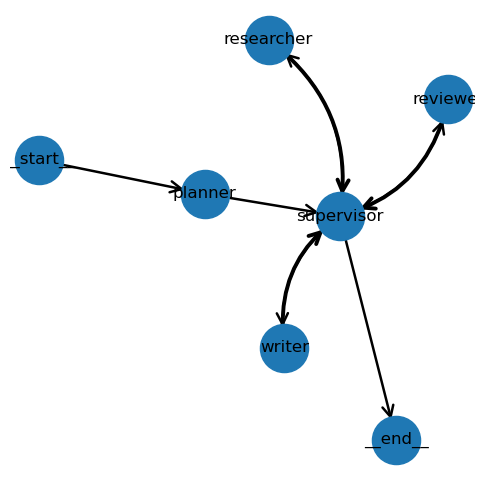

In [35]:
import networkx as nx
import matplotlib.pyplot as plt


g_vis = app.get_graph()
G = nx.DiGraph()
for edge in g_vis.edges:
    G.add_edge(edge.source, edge.target)

pos = nx.spring_layout(G)



def draw_bidirectional(G, pos=None, rad=0.3):
    if pos is None:
        pos = nx.spring_layout(G)

    plt.figure(figsize=(6, 6))

    drawn = set()

    # ---- draw edges first (so nodes can go on top) ----
    for u, v in G.edges():
        if (v, u) in G.edges() and (v, u) not in drawn:
            # curved u → v
            nx.draw_networkx_edges(
                G, pos,
                edgelist=[(u, v)],
                arrowstyle="->",
                arrowsize=20,
                min_source_margin=15,
                min_target_margin=15,
                connectionstyle=f"arc3,rad={rad}",
                width=1.8
            )
            # curved v → u
            nx.draw_networkx_edges(
                G, pos,
                edgelist=[(v, u)],
                arrowstyle="->",
                arrowsize=20,
                min_source_margin=15,
                min_target_margin=15,
                connectionstyle=f"arc3,rad={-rad}",
                width=2.8
            )
            drawn.add((u, v))
            drawn.add((v, u))

        elif (u, v) not in drawn:
            # single-direction → straight
            nx.draw_networkx_edges(
                G, pos,
                edgelist=[(u, v)],
                arrowstyle="->",
                arrowsize=20,
                min_source_margin=15,
                min_target_margin=15,
                connectionstyle="arc3,rad=0.0",
                width=1.8
            )
            drawn.add((u, v))

    # ---- now draw nodes and labels on top ----
    nx.draw_networkx_nodes(G, pos, node_size=1200)
    nx.draw_networkx_labels(G, pos, font_size=12)

    plt.axis("off")
    plt.show()

draw_bidirectional(G)


In [36]:
import ipycytoscape as cy

# Create Cytoscape widget
cy_graph = cy.CytoscapeWidget()
cy_graph.graph.add_graph_from_networkx(G)

# Optional: simple styling (color start/end differently)
cy_graph.set_style([
    {
        "selector": "node",
        "style": {
            "label": "data(id)",
            "background-color": "#66b3ff",
            "font-size": "10px"
        }
    },
    {
        "selector": 'node[id = "__start__"]',
        "style": {
            "background-color": "#4caf50",  # green
            "shape": "round-rectangle"
        }
    },
    {
        "selector": 'node[id = "__end__"]',
        "style": {
            "background-color": "#f44336",  # red
            "shape": "round-rectangle"
        }
    },
    {
        "selector": "edge",
        "style": {
            "curve-style": "bezier",
            "target-arrow-shape": "triangle",
            "line-color": "#999",
            "target-arrow-color": "#999"
        }
    },
])

cy_graph  # <-- in Jupyter/VSCode this shows the interactive DAG

2025-11-16 10:33:37,370 - numexpr.utils - INFO - utils.py:148 - _init_num_threads() - Note: NumExpr detected 16 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
2025-11-16 10:33:37,370 - numexpr.utils - INFO - utils.py:160 - _init_num_threads() - NumExpr defaulting to 8 threads.


CytoscapeWidget(cytoscape_layout={'name': 'cola'}, cytoscape_style=[{'selector': 'node', 'style': {'label': 'd…